# Bank Customer Churn Analysis 

In the competitive banking market, customer retention is the ultimate driver of sustainable growth. This project analyzes (Bank+Customer+Churn) to shift the bank from reactive customer service to proactive, data driven retention

# Why Bank Churn Matters

In the real world, bank churn is a critical profitability issue. Becuase acquiring ne customers is far costlier than retaining existing ones, high churn directly erodes long_term revenue and signals potential failures in customer service, product competitiveness or digital experience

# Objective
To provide actionable insights that allow the bank to intervene early, optimize retention efforts and reduce avoidable revenue loss

# Scope of work
1. Data loading and inspection
2. Data cleaning
3. Exploratory analysis
4. Key Findings

## 1. Data Loading and Inspection

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Bank/Bank_Churn.csv")
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1015.8 KB


In [3]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Checking for missing values

In [4]:
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### The above code indicates there is no missing value

### Checking for duplicates

In [5]:
df.duplicated().sum()

np.int64(0)

### The above code indicataes there is no duplicate

### 2. Data Cleaning

In [6]:
df.rename(columns={"Geography": "Country"}, inplace=True)
df.head()

,CustomerId,Surname,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 2.1 Adding and removing of columns
The AnActiveMember was created using IsActiveMember, same principle is applied on HasACrCard and HasCrCard. Afterwards IsActiveMember and HasACrCard were removed to avoid confusion

In [7]:
df["AnActiveMember"]=df["IsActiveMember"].apply(lambda x: "Yes" if x==1 else "No")
df["HasACrCard"]=df["HasCrCard"].apply(lambda x: "Yes" if x==1 else "No")
df["exited"]=df["Exited"].apply(lambda x: "Yes" if x==1 else "No")
df.head()

,CustomerId,Surname,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AnActiveMember,HasACrCard,exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Yes,Yes,Yes
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Yes,No,No
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,No,Yes,Yes
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,No,No,No
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Yes,Yes,No


In [8]:
df.drop(columns={"IsActiveMember", "HasCrCard"}, inplace=True)
df.head()

,CustomerId,Surname,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited,AnActiveMember,HasACrCard,exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,101348.88,1,Yes,Yes,Yes
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,112542.58,0,Yes,No,No
2,15619304,Onio,502,France,Female,42,8,159660.80,3,113931.57,1,No,Yes,Yes
3,15701354,Boni,699,France,Female,39,1,0.00,2,93826.63,0,No,No,No
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,79084.10,0,Yes,Yes,No


In [9]:
df.drop(columns={"Exited"},inplace=True)
df.head()

,CustomerId,Surname,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,AnActiveMember,HasACrCard,exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,101348.88,Yes,Yes,Yes
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,112542.58,Yes,No,No
2,15619304,Onio,502,France,Female,42,8,159660.80,3,113931.57,No,Yes,Yes
3,15701354,Boni,699,France,Female,39,1,0.00,2,93826.63,No,No,No
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,79084.10,Yes,Yes,No


## 4. Exploratory Analysis
### 1. The country with the highest usage

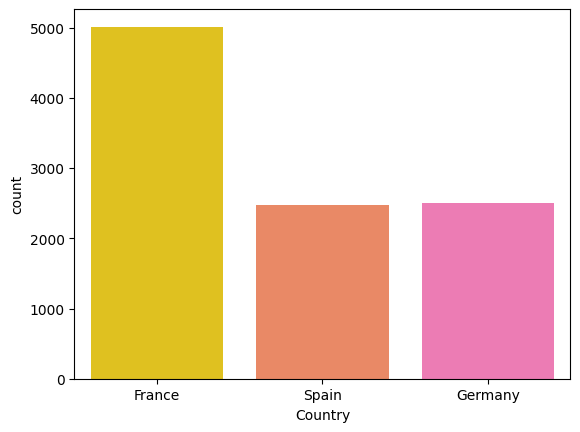

In [20]:
sns.countplot(data=df, x="Country", hue="Country", palette={"France":"gold", "Germany": "hotpink", "Spain": "coral"})
plt.show()

### 2. What is the overall exit rate?

In [11]:
df["exited"].value_counts(normalize=True)*100

exited
No     79.63
Yes    20.37
Name: proportion, dtype: float64

### 3. Do customers in certain countries exit more?

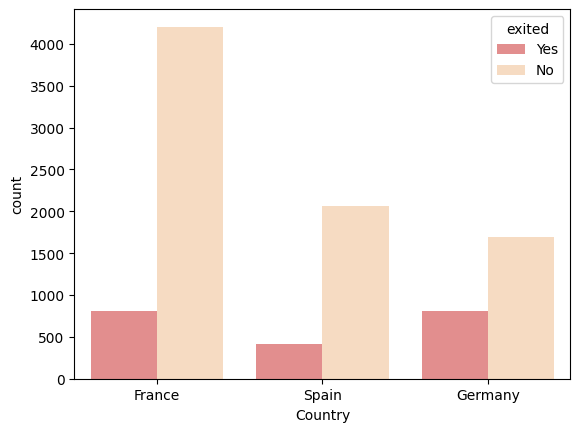

In [18]:
sns.countplot(data=df, x="Country", hue="exited", palette={"Yes": "lightcoral", "No": "peachpuff"})
plt.show()

### 4. What is the exit rate of active members?

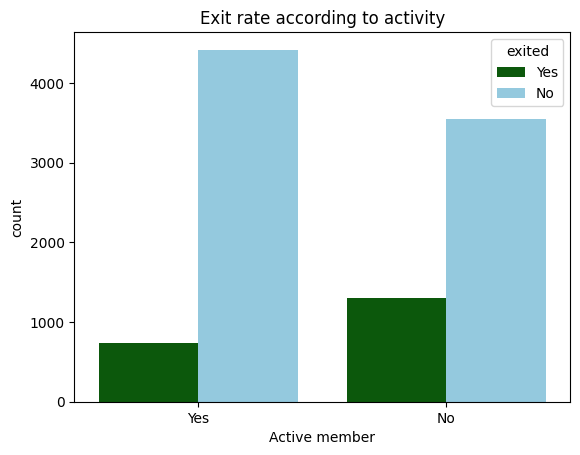

In [17]:
sns.countplot(data=df, x="AnActiveMember", hue="exited", palette={"Yes":"darkgreen", "No":"skyblue"})
plt.title("Exit rate according to activity")
plt.xlabel("Active member")
plt.show()

### 5. Is age a factor that affects exit rate?

C:\Users\DELL\AppData\Local\Temp\ipykernel_13612\2551946608.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="exited", y="Age", palette={"Yes":"maroon","No":"forestgreen"})


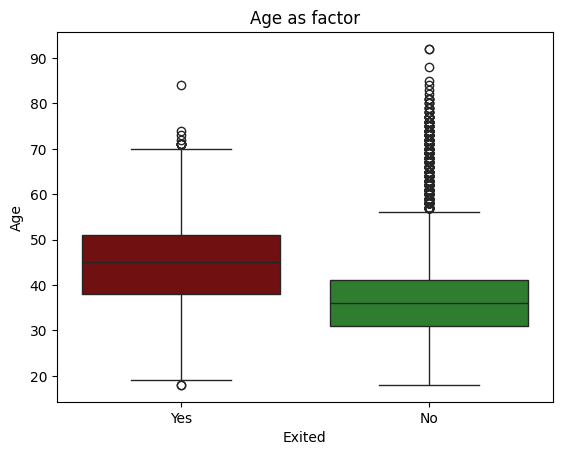

In [21]:
sns.boxplot(data=df, x="exited", y="Age", palette={"Yes":"maroon","No":"forestgreen"})
plt.title("Age as factor")
plt.xlabel("Exited")
plt.ylabel("Age")
plt.show()

### 6. Does balance affect exit rate?

C:\Users\DELL\AppData\Local\Temp\ipykernel_13612\2475532663.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="exited", y="Balance", palette={"Yes":"midnightblue", "No":"slategrey"})


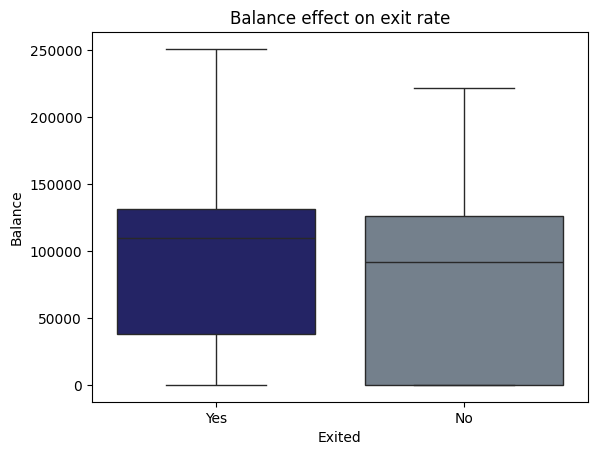

In [23]:
sns.boxplot(data=df, x="exited", y="Balance", palette={"Yes":"midnightblue", "No":"slategrey"})
plt.title("Balance effect on exit rate")
plt.xlabel("Exited")
plt.ylabel("Balance")
plt.show()

### 7. Does having a credit card matter?

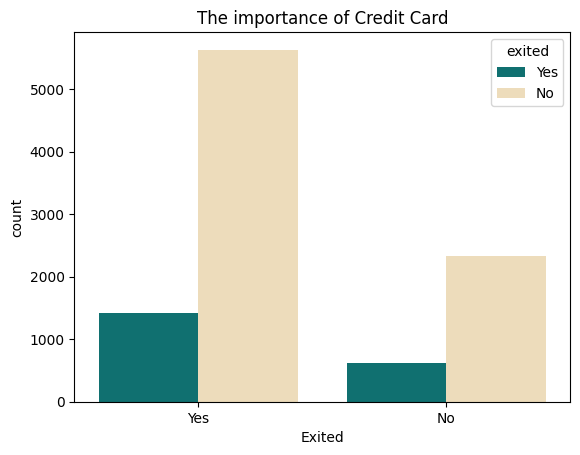

In [26]:
sns.countplot(data=df, x="HasACrCard", hue="exited", palette={"Yes":"teal", "No":"wheat"})
plt.title("The importance of Credit Card")
plt.xlabel("Exited")
plt.show()

# Key Findings

Based on the programmatic data adjustments and analysis executed above, the following structural insights were uncovered:

1. France is the country with the most users, having the least amount of exits adn germany having the most amount of exits
2. Shows the importance of having a credit card
3. A retention in Active members list